# DCIR Simulation with PyBaMM

This notebook demonstrates how to perform Direct Current Internal Resistance (DCIR) simulation using PyBaMM with BYD Blade Prismatic 135Ah cell parameters.

## Overview
- **Cell**: BYD Blade Prismatic 135Ah LFP
- **Chemistry**: LFP (Lithium Iron Phosphate)
- **Form Factor**: Prismatic
- **Nominal Voltage**: 3.3V
- **Capacity**: 135Ah
- **Simulations**: DCIR (7 time points)

In [1]:
# Import required libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm
from pathlib import Path
from scipy import interpolate
from model_library import simulate_dcir

# Helper functions


## 1. Load Cell Parameters

Load the cell design from the manifest file.

In [2]:
# Load cell manifest
# manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
manifest_path = Path("../cells/BYD_Blade_Prismatic_135Ah_manifest.json")

with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)

# ============================================================================
# OPERATING CONDITIONS FOR DCIR TEST
# ============================================================================
dcir_config = {
    "temperature_K": 298.15,  # 25°C
    "initial_soc": 0.5,  # 50% SOC
    "c_rate": 1.0,  # 1C discharge
    "direction": "discharge",
    "duration_s": 30,
}


## 2. Setup PyBaMM Model Parameters

Configure PyBaMM SPMe (Single Particle Model with electrolyte effects) using the cell design parameters.

For LFP cells, we use the **Prada2013** parameter set.

In [3]:
dcir_df = simulate_dcir(cell_design_manifest=cell_design_manifest, simulation_config=dcir_config)


Step 1: Updating cell parameters from manifest
  ✓ Design parameters updated
  ✓ Positive electrode parameters updated
  ✓ Negative electrode parameters updated
  ✓ Separator parameters updated
  ✓ Thermal parameters updated
  ✓ Operating conditions updated

Step 3: Capacity matching - Calibrating electrode width to match BYD 135Ah capacity
Target capacity: 135.707 Ah
Maximum iterations: 20
Convergence tolerance: 0.010%

Starting iterative capacity matching...
--------------------------------------------------------------------------------
Iteration  1: Capacity = 142.73 Ah, Scale = 1.0518, Error =  5.178%
Iteration  2: Capacity = 135.64 Ah, Scale = 0.9995, Error =  0.051%
Iteration  3: Capacity = 135.71 Ah, Scale = 1.0000, Error =  0.001%
--------------------------------------------------------------------------------
✓ Converged after 3 iterations!
  Final capacity: 135.71 Ah
  Target capacity: 135.707 Ah
  Error: 0.0005%

Calibrated OCV window:
  OCV at 100% SOC: 3.4196 V
  OCV at 

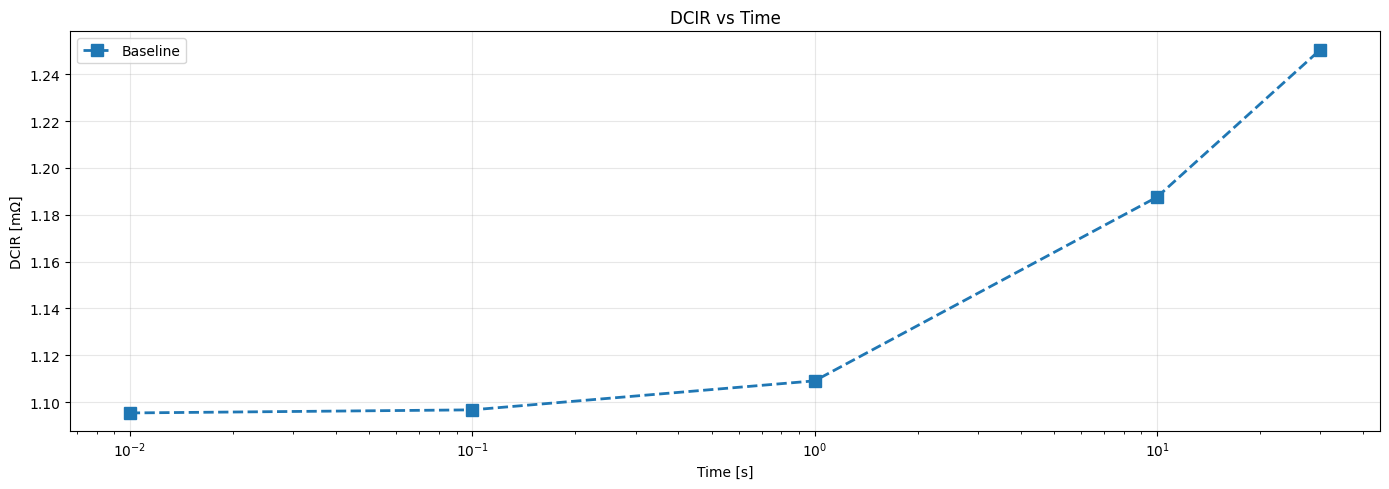

In [4]:
# Visualize results
fig, ax1 = plt.subplots(1, 1, figsize=(14, 5))
    
# DCIR vs Time
ax1.plot([r['time'] for r in dcir_df], [r['dcir'] for r in dcir_df], 
         's--', label='Baseline', linewidth=2, markersize=8)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('DCIR [mΩ]')
ax1.set_title('DCIR vs Time')
ax1.set_xscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
    
    
print("\n" + "="*80)